# Binary Classification for predicting hospital stay over certain length
<!-- @md-modelname -->
A model to predict if the length of the stay at a hospital is over the mean length of stay of a population.
<!-- /md-modelname -->

## Basic information
<!-- @md-basicinformation -->
This model is partly developed by Avinash Bhat at McGill University, on November 29, 2021. This is a combination of a Logistic Regression and Doc2Vec model. The model is available to all under a MIT license.
<!-- /md-basicinformation -->

## Intended Use
<!-- @md-intendeduse -->
The model predicts if the length of stay of a patient who is admitted to a hospital crosses the mean length of stay of a population. The model is developed from a subset of a larger dataset (MIMIC-III). The model is trained on a handful of features and serves only for experimentation around machine learning algorithm and certain developer tools.
<!-- /md-intendeduse -->

## Problem Definition
This model was built for a hypothetical program providing early health and financial counseling to patients expected to experience a prolonged length of stay in an intensive care unit (ICU) ward. The service is paid for by small donations from the community it serves. The length of stay for this program can be predicted with reasonable performance, and we need to ensure that resources are distributed among the benefitted patients fairly. 

We model this as a binary classification problem where we predict whether or not the length of stay for a given admission is greater than the mean.

## Libraries
<!-- @md-libraries -->
The model plotting functions from matplotlib, machine learning implementations from tensorflow, and pandas for data structure and transformations.
<!-- /md-libraries -->

In [1]:
# Standard Libraries
import numpy as np
import pandas as pd
import warnings
from math import log
import multiprocessing
import pickle

# Load plotting libraries
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pywaffle import Waffle

# Load Prediction Libraries
from sklearn.model_selection import train_test_split, GridSearchCV, RepeatedStratifiedKFold
from sklearn.linear_model import LogisticRegression
from gensim.models.doc2vec import Doc2Vec, TaggedDocument
from sklearn.metrics import accuracy_score, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.exceptions import ConvergenceWarning
from gensim.models import Doc2Vec

# Remove limit to the number of columns and column widths displayed by pandas
pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 0)

warnings.filterwarnings('ignore')

cores = multiprocessing.cpu_count()

## Dataset
<!-- @md-datasets -->
The dataset is a subset of the [MIMIC-III](https://www.nature.com/articles/sdata201635) dataset, and is downloaded from [Kaggle](https://www.kaggle.com/drscarlat/mimic3d).
<!-- /md-datasets -->

In [2]:
# [model card] stage: Ignore
# Loading the data
df = pd.read_csv("mimic3d.csv")

In [3]:
# Visualise the dataset
df.head(3)

,hadm_id,gender,age,LOSdays,admit_type,admit_location,AdmitDiagnosis,insurance,religion,marital_status,ethnicity,NumCallouts,NumDiagnosis,NumProcs,AdmitProcedure,NumCPTevents,NumInput,NumLabs,NumMicroLabs,NumNotes,NumOutput,NumRx,NumProcEvents,NumTransfers,NumChartEvents,ExpiredHospital,TotalNumInteract,LOSgroupNum
0,100001,F,35,6.17,EMERGENCY,CLINIC REFERRAL/PREMATURE,DIABETIC KETOACIDOSIS,Private,PROTESTANT QUAKER,DIVORCED,WHITE,0.16,2.59,0.00,na,1.30,25.12,43.44,0.65,0.05,5.19,14.91,1.13,0.65,398.70,0,493.89,1
1,100003,M,59,4.04,EMERGENCY,EMERGENCY ROOM ADMIT,UPPER GI BLEED,Private,NOT SPECIFIED,SINGLE,WHITE,0.25,2.23,0.99,Endosc control gast hem,1.98,13.61,55.94,1.24,1.59,5.45,7.18,0.99,1.24,373.02,0,465.71,1
2,100006,F,48,12.04,EMERGENCY,EMERGENCY ROOM ADMIT,COPD FLARE,Private,NOT SPECIFIED,SINGLE,BLACK/AFRICAN AMERICAN,0.00,0.75,0.17,Non-invasive mech vent,0.83,11.46,33.39,0.33,0.15,4.15,6.23,0.00,0.33,286.21,0,344.00,3


## Choosing the required columns <a id="datasubset"></a>

## Preprocessing
<!-- @md-preprocessing -->
Since the dataset seems to have sufficient rows, we will just try to remove the null rows rather than any data augmentation for missing values.

Except for age, other rows are categorical values. The column has datapoints at the age of 0 (birth). We choose not to perform any standardization to the continuous variables in order to retain this distinction in the data.

The two columns 'DIAGNOSIS' and 'PROCEDURE' have strings in them which are cleaned by converting the strings to uppercase, and removing any white space in them. The string in the dataframe is replaced by a tokenised list of strings.

The feature of ETHNICITY has a large number of classes, so we bucket these into bigger classes manually.
<!-- /md-preprocessing -->

In [4]:
# [model card] stage: Preprocessing
# We choose a subset of this data for our experiment
df = df[['age', 'insurance', 'religion', 'marital_status', 'ethnicity', 'LOSdays', 'gender', 'AdmitDiagnosis', 'AdmitProcedure', 'admit_type']]
df = df.rename(columns={"age": "AGE", "AdmitDiagnosis": "DIAGNOSIS", "insurance": "INSURANCE", "religion": "RELIGION", "marital_status": "MARRIED", "ethnicity": "ETHNICITY", "gender": "GENDER", "LOSdays": "LENGTH_OF_STAY", "admit_type": "ADMIT_TYPE", "AdmitProcedure": "PROCEDURE" })

In [5]:
df.head(3)

,AGE,INSURANCE,RELIGION,MARRIED,ETHNICITY,LENGTH_OF_STAY,GENDER,DIAGNOSIS,PROCEDURE,ADMIT_TYPE
0,35,Private,PROTESTANT QUAKER,DIVORCED,WHITE,6.17,F,DIABETIC KETOACIDOSIS,na,EMERGENCY
1,59,Private,NOT SPECIFIED,SINGLE,WHITE,4.04,M,UPPER GI BLEED,Endosc control gast hem,EMERGENCY
2,48,Private,NOT SPECIFIED,SINGLE,BLACK/AFRICAN AMERICAN,12.04,F,COPD FLARE,Non-invasive mech vent,EMERGENCY


In [6]:
df.shape

(58976, 10)

## Data Cleaning
<!-- @md-datacleaning -->
We remove any null values from the given data.
<!-- /md-datacleaning -->

In [7]:
# [model card] stage: Data Cleaning
df[df.PROCEDURE == 'na'] = float("nan")
df.dropna(inplace=True)

In [8]:
df.shape

(41608, 10)

In [9]:
# [model card] stage: Preprocessing
ethnicity_buckets = {
        'ASIAN - CHINESE': 'ASIAN', 
        'UNABLE TO OBTAIN': 'UNKNOWN/NOT SPECIFIED',
        'HISPANIC OR LATINO': 'HISPANIC/LATINO',
        'HISPANIC/LATINO - PUERTO RICAN': 'HISPANIC/LATINO',
        'WHITE - RUSSIAN': 'WHITE',
        'BLACK/CAPE VERDEAN':'BLACK',
        'BLACK/AFRICAN AMERICAN': 'BLACK',
        'BLACK/HAITIAN': 'BLACK',
        'ASIAN - ASIAN INDIAN': 'ASIAN',
        'WHITE - OTHER EUROPEAN': 'WHITE',
        'HISPANIC/LATINO - DOMINICAN': 'HISPANIC/LATINO',
        'WHITE - BRAZILIAN': 'WHITE',
        'ASIAN - VIETNAMESE': 'ASIAN',
        'HISPANIC/LATINO - GUATEMALAN': 'HISPANIC/LATINO',
        'BLACK/AFRICAN': 'BLACK',
        'HISPANIC/LATINO - CUBAN': 'HISPANIC/LATINO',
        'WHITE - EASTERN EUROPEAN': 'WHITE', 
        'ASIAN - FILIPINO': 'ASIAN',
        'ASIAN - CAMBODIAN': 'ASIAN',
        'HISPANIC/LATINO - SALVADORAN': 'HISPANIC/LATINO',
        'ASIAN - OTHER': 'ASIAN',
        'ASIAN - KOREAN': 'ASIAN',
        'HISPANIC/LATINO - CENTRAL AMERICAN (OTHER)': 'HISPANIC/LATINO',
        'HISPANIC/LATINO - COLOMBIAN': 'HISPANIC/LATINO',
        'HISPANIC/LATINO - MEXICAN': 'HISPANIC/LATINO',
        'ASIAN - THAI':'ASIAN',
        'HISPANIC/LATINO - HONDURAN': 'HISPANIC/LATINO',
        'ASIAN - JAPANESE': 'ASIAN',
        'AMERICAN INDIAN/ALASKA NATIVE FEDERALLY RECOGNIZED TRIBE': 'AMERICAN INDIAN/ALASKA NATIVE'
}
df = df.replace({"ETHNICITY": ethnicity_buckets})

[Text(0.5, 1.0, 'Distribution of Age across the dataset'),
 Text(0, 0.5, 'Frequency')]

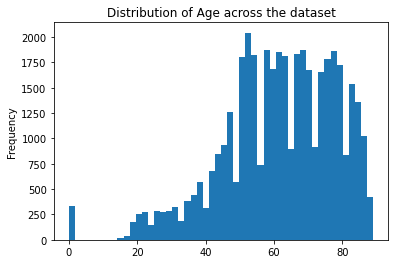

In [10]:
plt.hist(df[['AGE']], bins=50)
plt.gca().set(title='Distribution of Age across the dataset', ylabel='Frequency')

<BarContainer object of 19 artists>

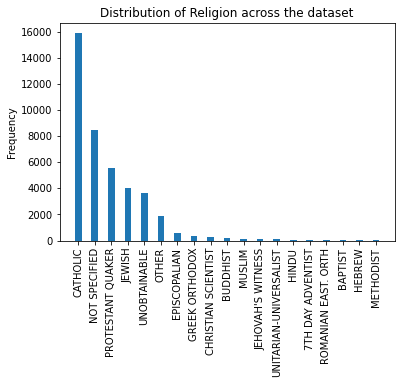

In [11]:
religion = df['RELIGION'].value_counts().to_dict()
plt.xticks(rotation='vertical')
plt.gca().set(title='Distribution of Religion across the dataset', ylabel='Frequency')
plt.bar(religion.keys(), religion.values(), width = 0.4)

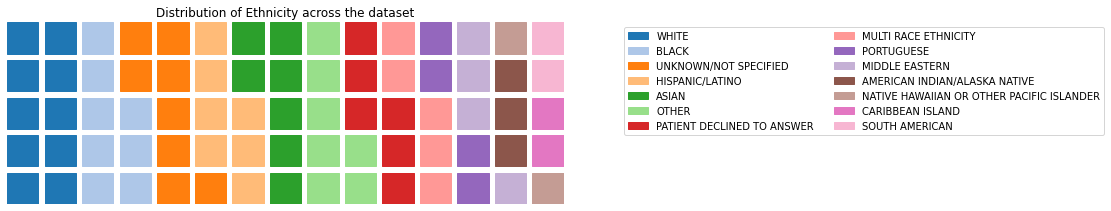

In [12]:
ethnicity = df['ETHNICITY'].value_counts().to_dict()
ethnicity = {d: log(v) for d, v in ethnicity.items()}
fig = plt.figure(
    FigureClass=Waffle, 
    figsize=(16, 10),
    rows=5, 
    values=ethnicity, 
    legend={'loc': 'best', 'bbox_to_anchor': (1.1, 1), 'ncol': 2}, 
    cmap_name="tab20"
)
plt.gca().set(title='Distribution of Ethnicity across the dataset')
plt.show()

In [13]:
# [model card] stage: Preprocessing
df['DIAGNOSIS'] = (df['DIAGNOSIS'].str.lower()
                           .str.replace(r'[^\w\s]+', '')
                           .str.strip()
                           .str.split())

In [14]:
# [model card] stage: Preprocessing
df['PROCEDURE'] = (df['PROCEDURE'].str.lower()
                           .str.replace(r'[^\w\s]+', '')
                           .str.strip()
                           .str.split())

In [15]:
df.head(3)

,AGE,INSURANCE,RELIGION,MARRIED,ETHNICITY,LENGTH_OF_STAY,GENDER,DIAGNOSIS,PROCEDURE,ADMIT_TYPE
1,59.0,Private,NOT SPECIFIED,SINGLE,WHITE,4.04,M,"[upper, gi, bleed]","[endosc, control, gast, hem]",EMERGENCY
2,48.0,Private,NOT SPECIFIED,SINGLE,BLACK,12.04,F,"[copd, flare]","[noninvasive, mech, vent]",EMERGENCY
3,73.0,Private,JEWISH,MARRIED,WHITE,7.29,F,"[bowel, obstruction]","[part, sm, bowel, resect, nec]",EMERGENCY


## Doc2Vec model using the 'DIAGNOSIS' parameter

We first choose the 'DIAGNOSIS' column and check what is the influence of this data on the length of stay.

In [16]:
documents = [TaggedDocument(doc, [" ".join(doc)]) for i, doc in enumerate(df['DIAGNOSIS'])]

In [17]:
d2v_model = Doc2Vec(min_count=20,
                     window=2,
                     vector_size=300,
                     sample=6e-5, 
                     alpha=0.03, 
                     min_alpha=0.0007, 
                     negative=20,
                     workers=cores-1)
d2v_model.build_vocab(documents)

Training the model to create the embeddings.

In [18]:
d2v_model.train(documents, total_examples=d2v_model.corpus_count, epochs=30, report_delay=1)
d2v_model.init_sims(replace=True)

The model implementation has a function called 'most_similar' that lets us get the words that are similar to the current word in the distribution.

## Creating the training and testing split

In [20]:
# [model card] stage: Model Training
X = [d2v_model.infer_vector(doc.words) for doc in documents]
y = df['LENGTH_OF_STAY'].apply(lambda x: 1 if x > df.LENGTH_OF_STAY.mean() else 0)
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

## Building a Logistic Regression model based on the 'DIAGNOSIS' data

In [21]:
# [model card] stage: Model Training
logreg_diagnosis = LogisticRegression(n_jobs=1, C=1e5)
logreg_diagnosis.fit(X_train, y_train)

LogisticRegression(C=100000.0, n_jobs=1)

In [22]:
pickle.dump(logreg_diagnosis, open('doc2vec-diagnosis.pkl', 'wb'))
logreg_diagnosis = pickle.load(open('doc2vec-diagnosis.pkl', 'rb'))

In [23]:
y_pred = logreg_diagnosis.predict(X_test)

In [24]:
print('Testing accuracy %s' % accuracy_score(y_test, y_pred))
print('Testing F1 score: {}'.format(f1_score(y_test, y_pred, average='weighted')))

Testing accuracy 0.6730353280461427
Testing F1 score: 0.5834332474666604


## Building a Logistic Regression model based on the categorical features

In [25]:
X = df[['AGE', 'INSURANCE', 'RELIGION', 'MARRIED', 'ETHNICITY', 'GENDER', 'ADMIT_TYPE']]
X = pd.get_dummies(X) # Convert the data into one hot encoded form

In [26]:
# [model card] stage: Ignore
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [27]:
# [model card] stage: Model Training
logreg = LogisticRegression(solver='liblinear', n_jobs=1, C=1e5)
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [28]:
print('Testing accuracy %s' % accuracy_score(y_test, y_pred))
print('Testing F1 score: {}'.format(f1_score(y_test, y_pred, average='weighted')))

Testing accuracy 0.6730353280461427
Testing F1 score: 0.5435241629530554


We could try to optimise this results by tuning the hyperparameters of the model.

## Hyperparameter Tuning for model based on categorical features
<!-- @md-hyperparameters -->
The [LogisticRegression implementation](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html) primarily has three hyperparameters that can be optimised on again.
- penalty: Can be l1 or the l2 norm.
- solver: Can be one of ‘newton-cg’, ‘lbfgs’, ‘liblinear’, ‘sag’, ‘saga’.
- C value: C value stands for inverse of regularization strength. This could be a float value, and we will try for the discrete values [100, 10, 1.0, 0.1, 0.01]
<!-- /md-hyperparameters -->

In [29]:
# [model card] stage: Hyperparameters
param_grid = [
  {
      'penalty': ['l1'], 
      'solver': ['liblinear', 'saga'], 
      'C': [100, 10, 1.0, 0.1, 0.01]
  },
  {
      'penalty': ['l2'], 
      'solver': ['liblinear', 'newton-cg', 'saga'], 
      'C': [100, 10, 1.0, 0.1, 0.01]
  }, 
  {
      'penalty': ['elasticnet'], 
      'solver': ['saga'], 
      'C': [100, 10, 1.0, 0.1, 0.01]
  }
 ]

In [30]:
# [model card] stage: Hyperparameters
# Please note that grid search takes a while to run, if you plan to rerun this cell
with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=ConvergenceWarning)
    grid_search = GridSearchCV(logreg, param_grid, scoring='accuracy', n_jobs=-1, cv=5)
    search_result = grid_search.fit(X_train, y_train)

In [31]:
print('Best Score: %s' % search_result.best_score_)
print('Best Hyperparameters: %s' % search_result.best_params_)

Best Score: 0.6738268311220088
Best Hyperparameters: {'C': 1.0, 'penalty': 'l2', 'solver': 'liblinear'}


In [32]:
logreg = LogisticRegression(solver='liblinear', C=1.0, penalty='l2')
logreg.fit(X_train, y_train)

LogisticRegression(solver='liblinear')

In [33]:
pickle.dump(logreg, open('logreg-categorical.pkl', 'wb'))
logreg = pickle.load(open('logreg-categorical.pkl', 'rb'))

In [34]:
y_pred = logreg.predict(X_test)

In [35]:
print('Testing accuracy %s' % accuracy_score(y_test, y_pred))
print('Testing F1 score: {}'.format(f1_score(y_test, y_pred, average='weighted')))

Testing accuracy 0.673155491468397
Testing F1 score: 0.5435826761367382


## Combining the Doc2Vec and the categorical models

In [36]:
# [model card] stage: Model Training
Xf = pd.DataFrame(pd.np.column_stack([[d2v_model.infer_vector(doc.words) for doc in documents], X]))
X_train, X_test, y_train, y_test = train_test_split(Xf, y, stratify=y, test_size=0.2, random_state=42)

In [37]:
# [model card] stage: Model Training
logreg = LogisticRegression(n_jobs=1, C=0.1, penalty='l2', solver='liblinear')
logreg.fit(X_train, y_train)
y_pred = logreg.predict(X_test)

In [38]:
print('Testing accuracy %s' % accuracy_score(y_test, y_pred))
print('Testing F1 score: {}'.format(f1_score(y_test, y_pred, average='weighted')))

Testing accuracy 0.6743571256909396
Testing F1 score: 0.5553224445290175


While there is a slight improvement in the accuracy and F1 score.

## [TASK2] Programming Task
Please finish the second task, select the best model and update the model documentation. 

In [39]:
# documents = ???

In [40]:
# d2v_model = ???
# d2v_model.build_vocab(???)

In [41]:
# d2v_model.train()

In [42]:
# Run this cell to optimise the memory (replace d2v_model by the specific variable you store the model in)
# d2v_model.init_sims(replace=True)

In [43]:
# X = ???

In [45]:
# This cell generates the target and splits the train and test. The code is meant as a pointer
# and you can either retain or modify the code 
# y = df['LENGTH_OF_STAY'].apply(lambda x: 1 if x > df.LENGTH_OF_STAY.mean() else 0)
# X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

In [46]:
# y_pred = ???.predict(X_test)

In [49]:
# This cell outputs the f1 and the accuracy score. The code is meant as a pointer
# and you can either retain or modify the code 
# print('Testing accuracy %s' % accuracy_score(y_test, y_pred))
# print('Testing F1 score: {}'.format(f1_score(y_test, y_pred, average='weighted')))

## References <a id="references"></a>
<!-- @md-references -->
### Citations  
Ahmad, M. A., Eckert, C., Kumar, V., Patel, A., & Teredesai, A. (2020). Fairness in Machine Learning for Healthcare. In Proceedings of the 26th ACM SIGKDD International Conference on Knowledge Discovery & Data Mining (bll 3529–3530).

Quoc Le and Tomas Mikolov. 2014. Distributed representations of sentences and documents. In <i>Proceedings of the 31st International Conference on International Conference on Machine Learning - Volume 32</i> (<i>ICML'14</i>). JMLR.org, II–1188–II–1196.
<!-- /md-references -->